# EV Intelligence — Power BI Dashboard Build

**Final dashboard preparation notebook**

### Layout
- **Row 1:** 3 equal visuals — EV trend, manufacturer volume, EV type mix
- **Row 2:** 3 equal visuals — state performance, range distribution, MSRP distribution
- **Row 3:** 1 wide portfolio visual + deep conditional-formatting summary table

### Recommended slicers
`Model_Year` · `State` · `Make` · `EV_Type` · `CAFV_Eligibility` · `Electric_Utility` · `County`

### Core KPIs
Total Vehicles · Manufacturers · Models · States · Avg/Median Range · Avg MSRP · BEV Share · PHEV Share · CAFV Eligible Share

> All calculations use the cleaned local dataset. No external dataset or website is required.

In [19]:
!pip install --upgrade matplotlib

   ---------------------------------------- 0.0/9.3 MB ? eta -:--:--
   ---------------------------------------- 0.0/9.3 MB ? eta -:--:--
   ---------------------------------------- 0.0/9.3 MB ? eta -:--:--
   - -------------------------------------- 0.3/9.3 MB ? eta -:--:--
   - -------------------------------------- 0.3/9.3 MB ? eta -:--:--
   - -------------------------------------- 0.3/9.3 MB ? eta -:--:--
   - -------------------------------------- 0.3/9.3 MB ? eta -:--:--
   - -------------------------------------- 0.3/9.3 MB ? eta -:--:--
   -- ------------------------------------- 0.5/9.3 MB 233.0 kB/s eta 0:00:38
   -- ------------------------------------- 0.5/9.3 MB 233.0 kB/s eta 0:00:38
   -- ------------------------------------- 0.5/9.3 MB 233.0 kB/s eta 0:00:38
   -- ------------------------------------- 0.5/9.3 MB 233.0 kB/s eta 0:00:38
   -- ------------------------------------- 0.5/9.3 MB 233.0 kB/s eta 0:00:38
   -- ------------------------------------- 0.5/9.3 MB 233

ERROR: Could not install packages due to an OSError: [WinError 5] Access is denied: 'c:\\users\\admin\\appdata\\roaming\\python\\python311\\site-packages\\matplotlib\\backends\\_backend_agg.cp311-win_amd64.pyd'
Consider using the `--user` option or check the permissions.



In [2]:
# 1. Load cleaned dataset
from pathlib import Path
import pandas as pd
import numpy as np
import plotly.express as px

pd.set_option("display.max_columns", 100)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")

# Project root
ROOT = Path("..").resolve()

# Cleaned dataset
DATA_PATH = ROOT / "datas" / "cleaned" / "ev_cleaned.csv"

if not DATA_PATH.exists():
    raise FileNotFoundError(f"Cleaned CSV not found: {DATA_PATH.resolve()}")

df = pd.read_csv(DATA_PATH)

print("Shape:", df.shape)
display(df.head())

Shape: (150482, 17)


C:\Users\Admin\AppData\Local\Temp\ipykernel_18824\936297917.py:19: DtypeWarning: Columns (0: Postal_Code, 1: Census_Tract) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(DATA_PATH)


,VIN,County,City,State,Postal_Code,Model_Year,Make,Model,EV_Type,CAFV_Eligibility,Electric_Range,Base_MSRP,Vehicle_ID,Vehicle_Location,Electric_Utility,Census_Tract,Legislative_District
0,KM8K33AGXL,King,Seattle,WA,"98,103.00",2020,HYUNDAI,KONA,Battery Electric Vehicle (BEV),Clean Alternative Fuel Vehicle Eligible,258,0,249675142,POINT (-122.34301 47.659185),CITY OF SEATTLE - (WA)|CITY OF TACOMA - (WA),"53,033,004,800.00",43
1,1C4RJYB61N,King,Bothell,WA,"98,011.00",2022,JEEP,GRAND CHEROKEE,Plug-in Hybrid Electric Vehicle (PHEV),Not eligible due to low battery range,25,0,233928502,POINT (-122.20578 47.762405),PUGET SOUND ENERGY INC||CITY OF TACOMA - (WA),"53,033,021,804.00",1
2,1C4RJYD61P,Yakima,Yakima,WA,"98,908.00",2023,JEEP,GRAND CHEROKEE,Plug-in Hybrid Electric Vehicle (PHEV),Not eligible due to low battery range,25,0,229675939,POINT (-120.6027202 46.5965625),PACIFICORP,"53,077,002,900.00",14
3,5YJ3E1EA7J,King,Kirkland,WA,"98,034.00",2018,TESLA,MODEL 3,Battery Electric Vehicle (BEV),Clean Alternative Fuel Vehicle Eligible,215,0,104714466,POINT (-122.209285 47.71124),PUGET SOUND ENERGY INC||CITY OF TACOMA - (WA),"53,033,021,903.00",45
4,WBY7Z8C5XJ,Thurston,Olympia,WA,"98,501.00",2018,BMW,I3,Plug-in Hybrid Electric Vehicle (PHEV),Clean Alternative Fuel Vehicle Eligible,97,0,185498386,POINT (-122.89692 47.043535),PUGET SOUND ENERGY INC,"53,067,010,700.00",22


In [4]:
# 2. Validate columns
required = [
    "VIN","County","City","State","Postal_Code","Model_Year","Make","Model",
    "EV_Type","CAFV_Eligibility","Electric_Range","Base_MSRP",
    "Legislative_District","Vehicle_ID","Vehicle_Location",
    "Electric_Utility","Census_Tract"
]
missing = [c for c in required if c not in df.columns]
if missing:
    raise KeyError(f"Missing columns: {missing}")

for c in ["Model_Year","Electric_Range","Base_MSRP"]:
    df[c] = pd.to_numeric(df[c], errors="coerce")

analysis_df = df.copy()
analysis_df["Vehicle_Count"] = 1
latest_year = int(analysis_df["Model_Year"].max())
analysis_df["Vehicle_Age"] = (latest_year - analysis_df["Model_Year"]).clip(lower=0)

analysis_df["Range_Band"] = pd.cut(
    analysis_df["Electric_Range"],
    [-np.inf,0,50,100,200,300,400,np.inf],
    labels=["0","1–50","51–100","101–200","201–300","301–400","400+"]
)

analysis_df["MSRP_Band"] = pd.cut(
    analysis_df["Base_MSRP"],
    [-np.inf,0,30000,50000,75000,100000,150000,np.inf],
    labels=["0","1–30K","30–50K","50–75K","75–100K","100–150K","150K+"]
)

print("Validation + feature engineering complete.")

Validation + feature engineering complete.


## 3. KPI layer

In [5]:
# Executive KPIs
total = len(analysis_df)
ev_text = analysis_df["EV_Type"].astype(str)
cafv_text = analysis_df["CAFV_Eligibility"].astype(str)

kpis = pd.DataFrame({
    "KPI": [
        "Total Vehicles","EV Manufacturers","EV Models","States Covered",
        "Average Electric Range","Median Electric Range","Average MSRP",
        "BEV Share %","PHEV Share %","CAFV Eligible Share %"
    ],
    "Value": [
        total,
        analysis_df["Make"].nunique(),
        analysis_df["Model"].nunique(),
        analysis_df["State"].nunique(),
        analysis_df["Electric_Range"].mean(),
        analysis_df["Electric_Range"].median(),
        analysis_df.loc[analysis_df["Base_MSRP"] > 0, "Base_MSRP"].mean(),
        ev_text.str.contains("Battery", case=False, na=False).mean()*100,
        ev_text.str.contains("Plug", case=False, na=False).mean()*100,
        cafv_text.str.contains("Eligible", case=False, na=False).mean()*100
    ]
})
display(kpis)

,KPI,Value
0,Total Vehicles,"150,482.00"
1,EV Manufacturers,37.00
2,EV Models,127.00
3,States Covered,41.00
4,Average Electric Range,67.88
5,Median Electric Range,18.00
6,Average MSRP,"57,172.04"
7,BEV Share %,77.62
8,PHEV Share %,22.38
9,CAFV Eligible Share %,53.68


## 4. Slicer profile

In [6]:
slicer_columns = [
    "Model_Year","State","Make","EV_Type",
    "CAFV_Eligibility","Electric_Utility","County"
]

slicer_profile = pd.DataFrame({
    "Slicer": slicer_columns,
    "Unique_Values": [analysis_df[c].nunique() for c in slicer_columns],
    "Business_Use": [
        "Time trend","Geography","Manufacturer","Technology",
        "Eligibility","Utility context","Local market"
    ]
})
display(slicer_profile)

,Slicer,Unique_Values,Business_Use
0,Model_Year,22,Time trend
1,State,41,Geography
2,Make,37,Manufacturer
3,EV_Type,2,Technology
4,CAFV_Eligibility,3,Eligibility
5,Electric_Utility,76,Utility context
6,County,183,Local market


## 5. Row 1 — Visual 1: EV trend

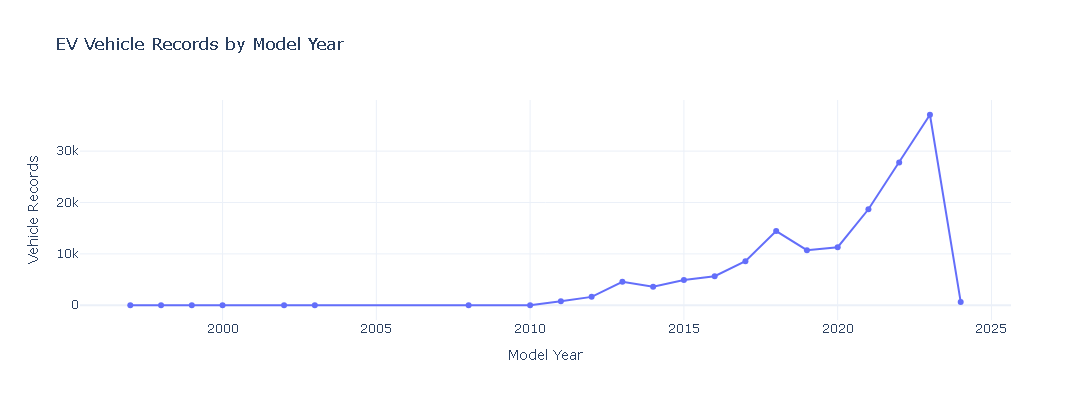

In [7]:
year_summary = (
    analysis_df.groupby("Model_Year", dropna=False)
    .agg(Vehicle_Count=("Vehicle_Count","sum"))
    .reset_index()
    .sort_values("Model_Year")
)
year_summary["Percentage"] = year_summary["Vehicle_Count"]/total*100

fig = px.line(
    year_summary, x="Model_Year", y="Vehicle_Count", markers=True,
    title="EV Vehicle Records by Model Year",
    labels={"Model_Year":"Model Year","Vehicle_Count":"Vehicle Records"}
)
fig.update_layout(template="plotly_white", height=400)
fig.show()

## 6. Row 1 — Visual 2: Manufacturer concentration

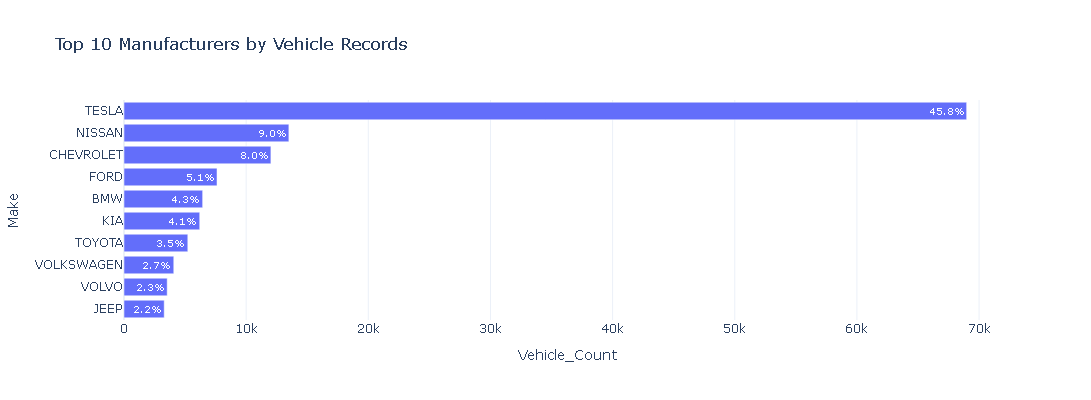

In [8]:
make_summary = (
    analysis_df.groupby("Make")
    .agg(Vehicle_Count=("Vehicle_Count","sum"),
         Models=("Model","nunique"),
         Avg_Range=("Electric_Range","mean"),
         Median_Range=("Electric_Range","median"),
         Avg_MSRP=("Base_MSRP","mean"))
    .reset_index()
)
make_summary["Percentage"] = make_summary["Vehicle_Count"]/total*100
top_make = make_summary.nlargest(10,"Vehicle_Count")

fig = px.bar(
    top_make.sort_values("Vehicle_Count"),
    x="Vehicle_Count", y="Make", orientation="h",
    text=top_make.sort_values("Vehicle_Count")["Percentage"].map(lambda x:f"{x:.1f}%"),
    title="Top 10 Manufacturers by Vehicle Records"
)
fig.update_layout(template="plotly_white", height=400)
fig.show()

## 7. Row 1 — Visual 3: EV technology mix

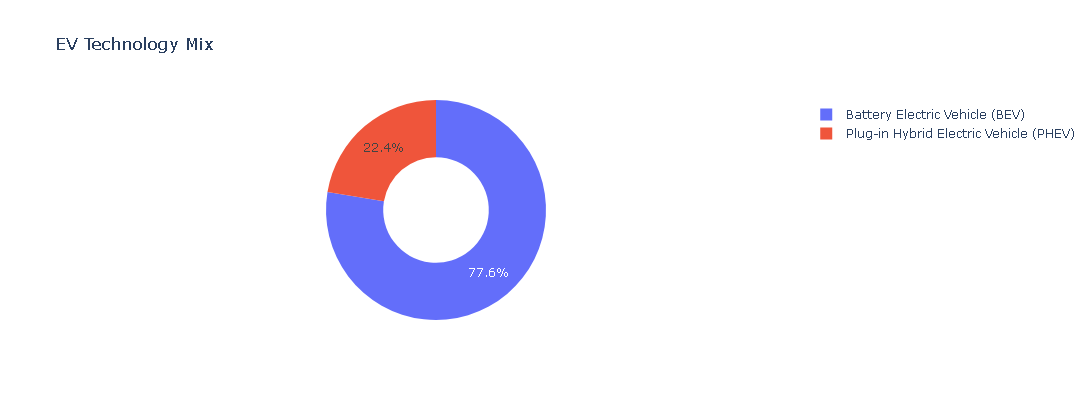

,EV_Type,Vehicle_Count,Percentage
0,Battery Electric Vehicle (BEV),116807,77.62
1,Plug-in Hybrid Electric Vehicle (PHEV),33675,22.38


In [9]:
ev_type_summary = (
    analysis_df.groupby("EV_Type")
    .agg(Vehicle_Count=("Vehicle_Count","sum"))
    .reset_index()
)
ev_type_summary["Percentage"] = ev_type_summary["Vehicle_Count"]/total*100

fig = px.pie(
    ev_type_summary, names="EV_Type", values="Vehicle_Count",
    hole=.48, title="EV Technology Mix"
)
fig.update_layout(template="plotly_white", height=400)
fig.show()

display(ev_type_summary.sort_values("Vehicle_Count", ascending=False))

## 8. Row 2 — Visual 4: State performance

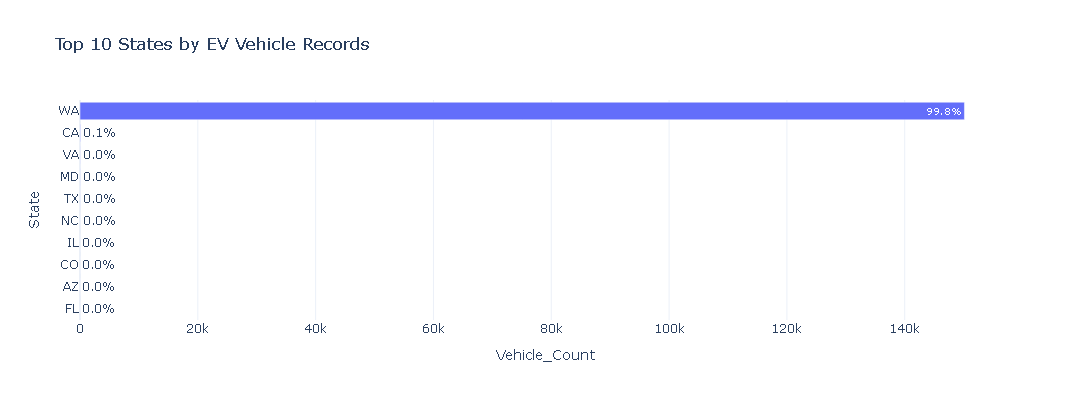

In [10]:
state_summary = (
    analysis_df.groupby("State")
    .agg(Vehicle_Count=("Vehicle_Count","sum"),
         Makes=("Make","nunique"),
         Models=("Model","nunique"),
         Avg_Range=("Electric_Range","mean"),
         Avg_MSRP=("Base_MSRP","mean"))
    .reset_index()
)
state_summary["Percentage"] = state_summary["Vehicle_Count"]/total*100
top_state = state_summary.nlargest(10,"Vehicle_Count")

fig = px.bar(
    top_state.sort_values("Vehicle_Count"),
    x="Vehicle_Count", y="State", orientation="h",
    text=top_state.sort_values("Vehicle_Count")["Percentage"].map(lambda x:f"{x:.1f}%"),
    title="Top 10 States by EV Vehicle Records"
)
fig.update_layout(template="plotly_white", height=400)
fig.show()

## 9. Row 2 — Visual 5: Electric range distribution

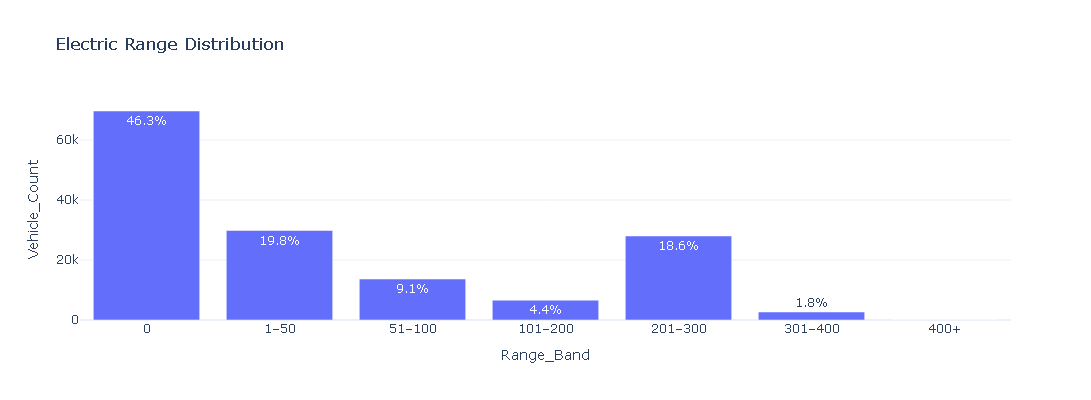

In [11]:
range_summary = (
    analysis_df.groupby("Range_Band", observed=False)
    .agg(Vehicle_Count=("Vehicle_Count","sum"))
    .reset_index()
)
range_summary["Percentage"] = range_summary["Vehicle_Count"]/total*100

fig = px.bar(
    range_summary, x="Range_Band", y="Vehicle_Count",
    text=range_summary["Percentage"].map(lambda x:f"{x:.1f}%"),
    title="Electric Range Distribution"
)
fig.update_layout(template="plotly_white", height=400)
fig.show()

## 10. Row 2 — Visual 6: MSRP distribution

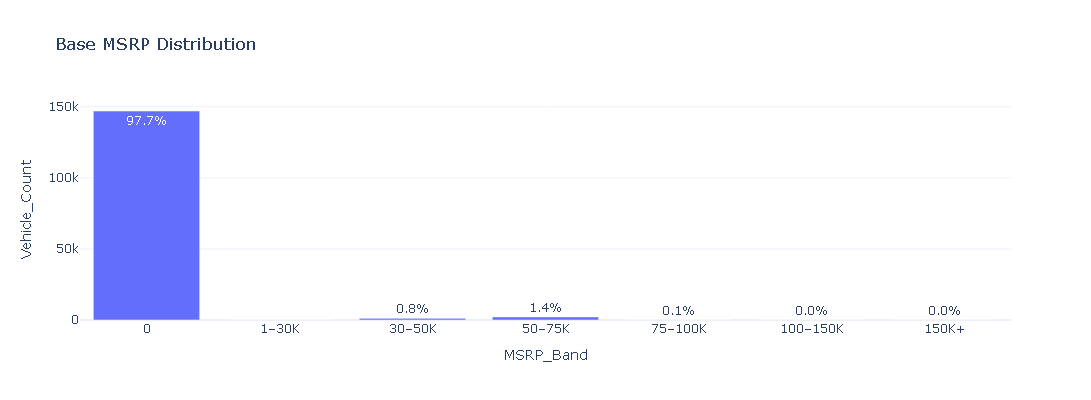

In [12]:
msrp_summary = (
    analysis_df.groupby("MSRP_Band", observed=False)
    .agg(Vehicle_Count=("Vehicle_Count","sum"))
    .reset_index()
)
msrp_summary["Percentage"] = msrp_summary["Vehicle_Count"]/total*100

fig = px.bar(
    msrp_summary, x="MSRP_Band", y="Vehicle_Count",
    text=msrp_summary["Percentage"].map(lambda x:f"{x:.1f}%"),
    title="Base MSRP Distribution"
)
fig.update_layout(template="plotly_white", height=400)
fig.show()

## 11. Row 3 — Wide portfolio analysis

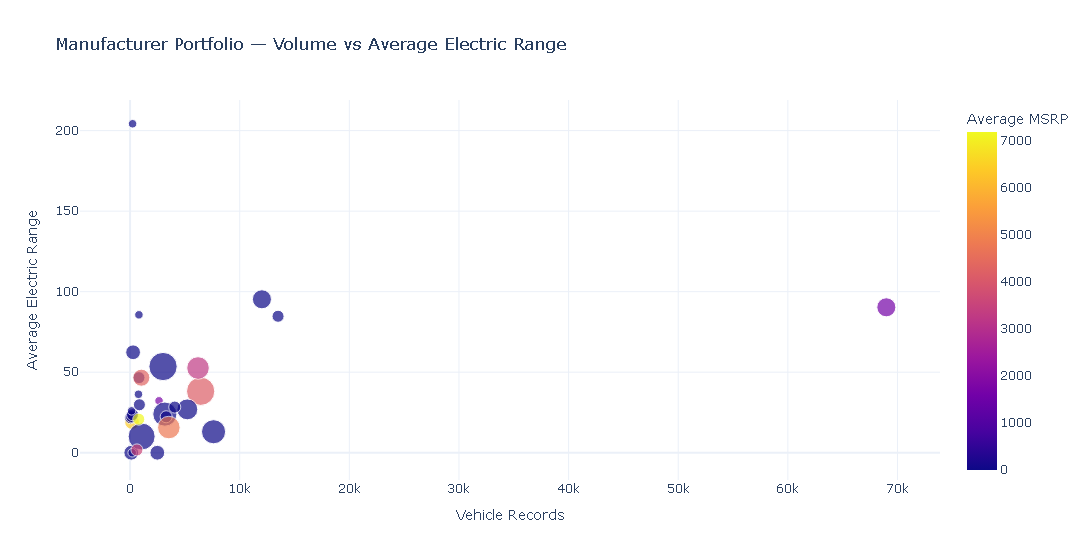

In [13]:
portfolio = (
    analysis_df.groupby("Make")
    .agg(
        Vehicle_Count=("Vehicle_Count","sum"),
        Models=("Model","nunique"),
        Avg_Range=("Electric_Range","mean"),
        Median_Range=("Electric_Range","median"),
        Avg_MSRP=("Base_MSRP","mean"),
        Median_MSRP=("Base_MSRP","median"),
        Avg_Vehicle_Age=("Vehicle_Age","mean")
    )
    .reset_index()
)
portfolio["Market_Share_%"] = portfolio["Vehicle_Count"]/total*100

portfolio_plot = portfolio[portfolio["Vehicle_Count"] >= 30]

fig = px.scatter(
    portfolio_plot,
    x="Vehicle_Count", y="Avg_Range", size="Models",
    color="Avg_MSRP", hover_name="Make",
    hover_data=["Models","Median_Range","Median_MSRP","Market_Share_%"],
    title="Manufacturer Portfolio — Volume vs Average Electric Range",
    labels={
        "Vehicle_Count":"Vehicle Records",
        "Avg_Range":"Average Electric Range",
        "Avg_MSRP":"Average MSRP",
        "Models":"Model Count"
    }
)
fig.update_layout(template="plotly_white", height=560)
fig.show()

## 12. Deep business summary table + conditional formatting

In [20]:
summary_table = portfolio.sort_values(
    ["Vehicle_Count", "Market_Share_%"],
    ascending=False
).copy()

overall_range = analysis_df["Electric_Range"].mean()

positive_msrp = analysis_df.loc[
    analysis_df["Base_MSRP"] > 0,
    "Base_MSRP"
]

overall_msrp = positive_msrp.mean()

summary_table["Volume_Rank"] = (
    summary_table["Vehicle_Count"]
    .rank(
        ascending=False,
        method="dense"
    )
    .astype(int)
)

summary_table["Range_vs_Overall_%"] = (
    summary_table["Avg_Range"]
    / overall_range
    * 100
)

summary_table["Price_vs_Overall_%"] = (
    summary_table["Avg_MSRP"]
    / overall_msrp
    * 100
)


# ============================================================
# FORMAT
# ============================================================

format_dict = {
    "Vehicle_Count": "{:,.0f}",
    "Models": "{:,.0f}",
    "Avg_Range": "{:,.1f}",
    "Median_Range": "{:,.1f}",
    "Avg_MSRP": "${:,.0f}",
    "Median_MSRP": "${:,.0f}",
    "Avg_Vehicle_Age": "{:,.1f}",
    "Market_Share_%": "{:.2f}%",
    "Range_vs_Overall_%": "{:.1f}%",
    "Price_vs_Overall_%": "{:.1f}%"
}


# ============================================================
# CUSTOM ROW/CELL STYLING
# ============================================================

def style_table(data):

    styles = pd.DataFrame(
        "",
        index=data.index,
        columns=data.columns
    )

    # -----------------------------
    # Market Share
    # -----------------------------
    if "Market_Share_%" in data.columns:
        for idx in data.index:
            value = data.loc[idx, "Market_Share_%"]

            if value >= 5:
                styles.loc[idx, "Market_Share_%"] = (
                    "background-color: #D9F2E6;"
                    "font-weight: bold;"
                )
            elif value >= 2:
                styles.loc[idx, "Market_Share_%"] = (
                    "background-color: #FFF0D6;"
                )

    # -----------------------------
    # Vehicle Volume
    # -----------------------------
    if "Vehicle_Count" in data.columns:
        threshold = data["Vehicle_Count"].median()

        for idx in data.index:
            value = data.loc[idx, "Vehicle_Count"]

            if value >= threshold:
                styles.loc[idx, "Vehicle_Count"] = (
                    "font-weight: bold;"
                    "background-color: #E0F0FF;"
                )

    # -----------------------------
    # Average Range
    # -----------------------------
    if "Avg_Range" in data.columns:
        for idx in data.index:
            value = data.loc[idx, "Avg_Range"]

            if value >= 200:
                styles.loc[idx, "Avg_Range"] = (
                    "background-color: #E0F0FF;"
                    "font-weight: bold;"
                )

    # -----------------------------
    # Average MSRP
    # -----------------------------
    if "Avg_MSRP" in data.columns:
        for idx in data.index:
            value = data.loc[idx, "Avg_MSRP"]

            if value >= 75000:
                styles.loc[idx, "Avg_MSRP"] = (
                    "background-color: #FFF0D6;"
                    "font-weight: bold;"
                )

    return styles


# ============================================================
# FINAL STYLED TABLE
# ============================================================

styled = (
    summary_table
    .head(20)
    .style
    .format(format_dict)
    .apply(style_table, axis=None)
    .set_caption(
        "EV Manufacturer Deep Performance Summary"
    )
    .set_properties(
        **{
            "text-align": "center",
            "padding": "8px"
        }
    )
)

display(styled)

,Make,Vehicle_Count,Models,Avg_Range,Median_Range,Avg_MSRP,Median_MSRP,Avg_Vehicle_Age,Market_Share_%,Volume_Rank,Range_vs_Overall_%,Price_vs_Overall_%
31,TESLA,"68,983",5,90.3,0.0,"$1,649",$0,3.4,45.84%,1,133.0%,2.9%
25,NISSAN,"13,497",2,84.7,84.0,$0,$0,7.2,8.97%,2,124.8%,0.0%
6,CHEVROLET,"12,026",5,95.3,53.0,$0,$0,5.8,7.99%,3,140.4%,0.0%
10,FORD,"7,614",8,13.0,19.0,$0,$0,5.1,5.06%,4,19.2%,0.0%
4,BMW,"6,439",11,38.2,30.0,"$4,154",$0,4.3,4.28%,5,56.2%,7.3%
16,KIA,"6,198",7,52.6,26.0,"$3,253",$0,3.0,4.12%,6,77.5%,5.7%
33,TOYOTA,"5,223",6,26.9,25.0,$0,$0,5.4,3.47%,7,39.7%,0.0%
34,VOLKSWAGEN,"4,074",2,28.3,0.0,$0,$0,3.1,2.71%,8,41.7%,0.0%
35,VOLVO,"3,536",7,15.6,18.0,"$4,786",$0,2.7,2.35%,9,23.0%,8.4%
15,JEEP,"3,292",2,22.3,21.0,$0,$0,1.6,2.19%,10,32.9%,0.0%


## 13. Power BI-ready export

The notebook creates the output folder automatically, so it does **not** depend on `outputs/powerbi/` already existing.

### Main model
- `fact_ev.csv`
- `dim_make.csv`
- `dim_model.csv`
- `dim_location.csv`
- `dim_ev_type.csv`
- `dim_cafv.csv`
- `dim_utility.csv`
- `dim_date.csv`

### Summary layer
- `kpis.csv`
- `year_summary.csv`
- `state_summary.csv`
- `manufacturer_summary.csv`
- `ev_type_summary.csv`
- `range_summary.csv`
- `msrp_summary.csv`
- `portfolio_matrix.csv`

In [16]:
# 14. Export everything for Power BI
BI_DIR = ROOT / "outputs" / "powerbi"
BI_DIR.mkdir(parents=True, exist_ok=True)

fact_cols = [
    "VIN","County","City","State","Postal_Code","Model_Year","Make","Model",
    "EV_Type","CAFV_Eligibility","Electric_Range","Base_MSRP",
    "Legislative_District","Vehicle_ID","Vehicle_Location","Electric_Utility",
    "Census_Tract","Vehicle_Age","Range_Band","MSRP_Band"
]
fact_ev = analysis_df[fact_cols].copy()
fact_ev.to_csv(BI_DIR/"fact_ev.csv", index=False)

dimensions = {
    "dim_make.csv": analysis_df[["Make"]].drop_duplicates().sort_values("Make"),
    "dim_model.csv": analysis_df[["Make","Model"]].drop_duplicates().sort_values(["Make","Model"]),
    "dim_location.csv": analysis_df[["State","County","City","Postal_Code"]].drop_duplicates(),
    "dim_ev_type.csv": analysis_df[["EV_Type"]].drop_duplicates().sort_values("EV_Type"),
    "dim_cafv.csv": analysis_df[["CAFV_Eligibility"]].drop_duplicates().sort_values("CAFV_Eligibility"),
    "dim_utility.csv": analysis_df[["Electric_Utility"]].drop_duplicates().sort_values("Electric_Utility"),
    "dim_date.csv": pd.DataFrame({"Model_Year": sorted(analysis_df["Model_Year"].dropna().unique())})
}
for name, table in dimensions.items():
    table.to_csv(BI_DIR/name, index=False)

exports = {
    "kpis.csv": kpis,
    "year_summary.csv": year_summary,
    "state_summary.csv": state_summary,
    "manufacturer_summary.csv": make_summary.sort_values("Vehicle_Count", ascending=False),
    "ev_type_summary.csv": ev_type_summary,
    "range_summary.csv": range_summary,
    "msrp_summary.csv": msrp_summary,
    "portfolio_matrix.csv": summary_table
}
for name, table in exports.items():
    table.to_csv(BI_DIR/name, index=False)

print("Export directory:", BI_DIR.resolve())
print("CSV files created:", len(list(BI_DIR.glob("*.csv"))))
display(pd.DataFrame({"File": sorted(p.name for p in BI_DIR.glob("*.csv"))}))

Export directory: D:\ev_project_v2-Data Analysis\outputs\powerbi
CSV files created: 25


,File
0,age_summary.csv
1,cafv_summary.csv
2,city_summary.csv
3,county_summary.csv
4,dim_cafv.csv
5,dim_date.csv
6,dim_ev_type.csv
7,dim_location.csv
8,dim_make.csv
9,dim_model.csv


## 15. Power BI page design

```text
ROW 1
[KPI] [KPI] [KPI] [KPI] [KPI]

SLICERS
[Model Year] [State] [Make] [EV Type] [CAFV] [Utility] [County]

ROW 2
[EV Trend]       [Top Manufacturers]       [EV Type Mix]

ROW 3
[State Performance] [Range Distribution]   [MSRP Distribution]

ROW 4
[Manufacturer Portfolio — WIDE]

ROW 5
[Deep Conditional-Formatting Summary Table]
```

### Recommended table formatting
- Vehicle Count → data bars / gradient
- Market Share % → percentage with 1–2 decimals
- Average Range → gradient
- Average MSRP → gradient
- Rank → integer
- Avoid treating `Base_MSRP = 0` as an actual price
- Use drill-through from manufacturer/state to the detailed fact table

In [17]:
# 16. Final quality gate
print("FINAL QUALITY GATE")
print("="*55)
print("Dataset rows:", len(analysis_df))
print("Dataset columns:", len(analysis_df.columns))
print("Null cells:", int(analysis_df.isna().sum().sum()))
print("Manufacturers:", analysis_df["Make"].nunique())
print("Models:", analysis_df["Model"].nunique())
print("States:", analysis_df["State"].nunique())
print("EV types:", analysis_df["EV_Type"].nunique())
print("Power BI CSV files:", len(list(BI_DIR.glob("*.csv"))))
print("Status: READY FOR POWER BI")


FINAL QUALITY GATE
Dataset rows: 150482
Dataset columns: 21
Null cells: 0
Manufacturers: 37
Models: 127
States: 41
EV types: 2
Power BI CSV files: 25
Status: READY FOR POWER BI


In [7]:
# ============================================================
# CSV / DataFrame → SQLite Database
# EV Data Analysis Project
# ============================================================

import sqlite3
from pathlib import Path

# ------------------------------------------------------------
# 1. Database path
# ------------------------------------------------------------
ROOT = Path("..").resolve()

DB_PATH = ROOT / "datas" / "database" / "ev_analysis.db"

# Create database folder
DB_PATH.parent.mkdir(parents=True, exist_ok=True)

# ------------------------------------------------------------
# 2. Check DataFrame
# ------------------------------------------------------------
if "df" not in globals():
    raise RuntimeError(
        "DataFrame 'df' is not loaded. Run the CSV loading cell first."
    )

print("DataFrame Shape:", df.shape)
print("Number of Columns:", len(df.columns))

# ------------------------------------------------------------
# 3. Connect to SQLite
# ------------------------------------------------------------
conn = sqlite3.connect(DB_PATH)

# ------------------------------------------------------------
# 4. Save DataFrame into SQLite
# ------------------------------------------------------------
df.to_sql(
    "ev_vehicles",
    conn,
    if_exists="replace",
    index=False
)

# ------------------------------------------------------------
# 5. Verify table
# ------------------------------------------------------------
tables = pd.read_sql_query(
    """
    SELECT name
    FROM sqlite_master
    WHERE type = 'table';
    """,
    conn
)

print("\nDatabase created successfully!")
print("Database Path:", DB_PATH.resolve())
print("\nTables:")
display(tables)

# ------------------------------------------------------------
# 6. Check row count
# ------------------------------------------------------------
row_count = pd.read_sql_query(
    "SELECT COUNT(*) AS total_rows FROM ev_vehicles;",
    conn
)

print("\nRow Count:")
display(row_count)

# ------------------------------------------------------------
# 7. Preview SQL table
# ------------------------------------------------------------
preview = pd.read_sql_query(
    """
    SELECT *
    FROM ev_vehicles
    LIMIT 10;
    """,
    conn
)

print("\nSQL Table Preview:")
display(preview)

# ------------------------------------------------------------
# 8. Close connection
# ------------------------------------------------------------
conn.close()

print("\nSQLite connection closed.")

DataFrame Shape: (150482, 68)
Number of Columns: 68

Database created successfully!
Database Path: D:\ev_project_v2-Data Analysis\datas\database\ev_analysis.db

Tables:


,name
0,ev_vehicles



Row Count:


,total_rows
0,150482



SQL Table Preview:


,VIN,County,City,State,Postal_Code,Model_Year,Make,Model,EV_Type,CAFV_Eligibility,Electric_Range,Base_MSRP,Vehicle_ID,Vehicle_Location,Electric_Utility,Census_Tract,Legislative_District,Vehicle_Age,Vehicle_Age_Group,Model_Year_Group,Has_Electric_Range,Range_Group,Range_Percentile,Range_ZScore,Has_MSRP,MSRP_Group,MSRP_Percentile,MSRP_ZScore,Range_per_MSRP,MSRP_per_Range,Range_Value_Group,Make_Share_Pct,State_Share_Pct,EV_Type_Share_Pct,CAFV_Share_Pct,Make_Rank,State_Rank,Model_Rank,Long_Range_Flag,Premium_MSRP_Flag,Recent_Model_Flag,Older_Model_Flag,High_Range_Premium_Flag,Model_Year_Decade,EV_Era,Range_Category,Range_Score,Price_Category,Log_MSRP,Range_per_10K_MSRP,Is_BEV,Is_PHEV,Manufacturer_Frequency,Manufacturer_Size,Model_Frequency,Model_Popularity,Location_Key,State_EV_Count,City_EV_Count,Utility_EV_Count,CAFV_Eligible_Flag,CAFV_Status,Has_Location,Has_Census_Tract,Has_Legislative_District,Has_VIN,Missing_Features_Count,Data_Completeness_Pct
0,KM8K33AGXL,King,Seattle,WA,"98,103.00",2020,HYUNDAI,KONA,Battery Electric Vehicle (BEV),Clean Alternative Fuel Vehicle Eligible,258,0,249675142,POINT (-122.34301 47.659185),CITY OF SEATTLE - (WA)|CITY OF TACOMA - (WA),"53,033,004,800.00",43,6,6-10 Years,2019-2021,1,201-300,94.01,1.98,0,0,48.85,-0.14,None,0.00,None,2.11,99.77,77.62,41.83,11.00,1.00,63.00,1,0,0,0,0,2020,Mainstream EV,Medium,3,Budget,0.00,None,1,0,3171,Very Large,208,Popular,WA_King,150141,25678,27268,1,Clean Alternative Fuel Vehicle Eligible,1,1,1,1,3,95.52
1,1C4RJYB61N,King,Bothell,WA,"98,011.00",2022,JEEP,GRAND CHEROKEE,Plug-in Hybrid Electric Vehicle (PHEV),Not eligible due to low battery range,25,0,233928502,POINT (-122.20578 47.762405),PUGET SOUND ENERGY INC||CITY OF TACOMA - (WA),"53,033,021,804.00",1,4,3-5 Years,2022-2023,1,1-50,55.98,-0.45,0,0,48.85,-0.14,None,0.00,None,2.19,99.77,22.38,11.85,10.00,1.00,36.00,0,0,0,0,0,2020,Mainstream EV,Very Low,1,Budget,0.00,None,0,1,3292,Very Large,663,Popular,WA_King,150141,4861,55637,1,Not eligible due to low battery range,1,1,1,1,3,95.52
2,1C4RJYD61P,Yakima,Yakima,WA,"98,908.00",2023,JEEP,GRAND CHEROKEE,Plug-in Hybrid Electric Vehicle (PHEV),Not eligible due to low battery range,25,0,229675939,POINT (-120.6027202 46.5965625),PACIFICORP,"53,077,002,900.00",14,3,3-5 Years,2022-2023,1,1-50,55.98,-0.45,0,0,48.85,-0.14,None,0.00,None,2.19,99.77,22.38,11.85,10.00,1.00,36.00,0,0,1,0,0,2020,Current EV,Very Low,1,Budget,0.00,None,0,1,3292,Very Large,663,Popular,WA_Yakima,150141,552,1102,1,Not eligible due to low battery range,1,1,1,1,3,95.52
3,5YJ3E1EA7J,King,Kirkland,WA,"98,034.00",2018,TESLA,MODEL 3,Battery Electric Vehicle (BEV),Clean Alternative Fuel Vehicle Eligible,215,0,104714466,POINT (-122.209285 47.71124),PUGET SOUND ENERGY INC||CITY OF TACOMA - (WA),"53,033,021,903.00",45,8,6-10 Years,2016-2018,1,201-300,85.10,1.53,0,0,48.85,-0.14,None,0.00,None,45.84,99.77,77.62,41.83,1.00,1.00,2.00,1,0,0,0,0,2010,Growing EV,Medium,3,Budget,0.00,None,1,0,68983,Very Large,27709,Highly Popular,WA_King,150141,4622,55637,1,Clean Alternative Fuel Vehicle Eligible,1,1,1,1,3,95.52
4,WBY7Z8C5XJ,Thurston,Olympia,WA,"98,501.00",2018,BMW,I3,Plug-in Hybrid Electric Vehicle (PHEV),Clean Alternative Fuel Vehicle Eligible,97,0,185498386,POINT (-122.89692 47.043535),PUGET SOUND ENERGY INC,"53,067,010,700.00",22,8,6-10 Years,2016-2018,1,51-100,75.06,0.30,0,0,48.85,-0.14,None,0.00,None,4.28,99.77,22.38,41.83,5.00,1.00,15.00,0,0,0,0,0,2010,Growing EV,Very Low,1,Budget,0.00,None,0,1,6439,Very Large,1917,Highly Popular,WA_Thurston,150141,3634,29865,1,Clean Alternative Fuel Vehicle Eligible,1,1,1,1,3,95.52
5,5YJ3E1EAXL,Snohomish,Marysville,WA,"98,271.00",2020,TESLA,MODEL 3,Battery Electric Vehicle (BEV),Clean Alternative Fuel Vehicle Eligible,266,0,124595523,POINT (-122.1713847 48.10433),PUGET SOUND ENERGY INC,"53,061,940,001.00",38,6,6-10 Years,2019-2021,1,201-300,95.32,2.06,0,0,48.85,-0.14,None,0.00,None,45.84,99.77,77.62,41.83,1.00,1.00,2.00,1,0,0,0,0,2020,Mainstream EV,Medium,3,Budget,0.00,None,1,0,689


SQLite connection closed.
